In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import scipy

from InSitu14CO import Propagator
import Functions_14CO as F

from tqdm import tqdm

from time import time

from scipy.interpolate import interp1d

from Firn_Model import Accumulation_Site

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '14' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
COS_partition = np.array(
    [#CO2         CO          CH4
    [0.686307104, 0.31125305, 0.002439846], # neutron
    [0.686307104, 0.31125305, 0.002439846], # neg muon
    [0.686307104, 0.31125305, 0.002439846], # fast muon
])

In [31]:
C14CO_const = 1
# setup Accumulation Site data
Dome_C = Accumulation_Site(C14CO_const = C14CO_const)

#L = np.array([1, *np.arange(6e-4,8e-4+1e-9, 1e-5)])
L = np.array([1, *np.arange(5e-4,1.4e-3+1e-9, 1e-4)])
#L = np.array([1, 7.1e-4])
#L = np.array([1, 1e-4, 5e-4, 8e-4, 9e-4, 1e-3, 2e-3, 1e-2, 1e-1])
#L = [0.0007]
# caculate cosmogenic 14C in reservoirs w/ Leakage rates L
C14_grains, C14_leak_open, C14_leak_closed, C14_cumuleak_closed = Dome_C.Calc_14C_ice(L=L)

# calculate 14CO concentrations in open porosity, + concentration trapped into closed porosity
C14_open_gas, C14_closed_gas, C14_open_atm, C14_closed_atm, c_gases = Dome_C.Calc_profiles(C14_leak_open)

/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:215: RuntimeWarning: invalid value encountered in divide
  bubble_pres = self.dz*(np.cumsum(dscl*C*self.s)*(1+np.log(v_ice)) - np.cumsum(dscl*C*self.s*np.log(v_ice)))/(self.s_closed-self.s_closed[0])/self.s
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:350: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:352: RuntimeWarning: invalid value encountered in multiply
  Ctemp = np.exp(-(lambd+Lrate)*COS_age) * np.cumsum((COS_P).reshape((-1,3,1)) * np.exp((lambd+Lrate)*COS_age) * COS_dt, axis=0)
/mnt/c/users/walte/Documents/python-scripts/In-Situ-14C/Firn_Model.py:571: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)
/home/wcook/.local/lib/python3.10/site-package

0.18240022659301758
interpolating...


100%|███████████████████████████████████████████████████████████████████████████████████| 34/34 [00:02<00:00, 11.80it/s]


integrating...
  Calculated open and closed profiles for gas 1 out of 1
6.439073801040649


Text(0.5, 1.0, 'Dome C Ice Density')

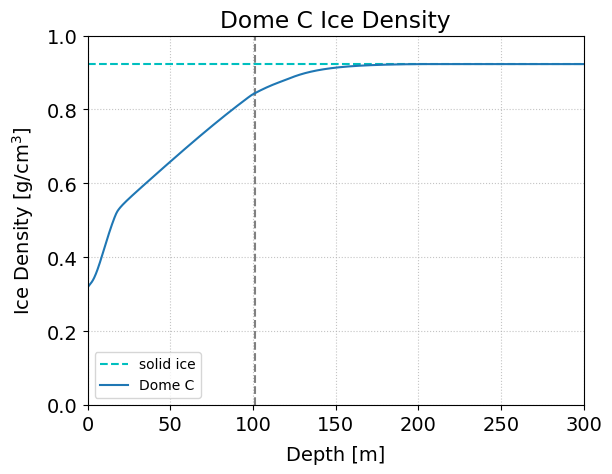

In [32]:
plt.axvline(Dome_C.z[Dome_C.teller_co], c='grey', ls='--')
plt.axhline(Dome_C.rho_ice, c='c', ls='--', label= 'solid ice')
plt.plot(Dome_C.z, Dome_C.rho, label='Dome C')
plt.xlabel('Depth [m]')
plt.xlim(Dome_C.z[0],Dome_C.z[-1])
plt.ylabel(r'Ice Density [g/cm$^3$]')
plt.ylim(0,1)
plt.legend(fontsize=10)
plt.title('Dome C Ice Density')

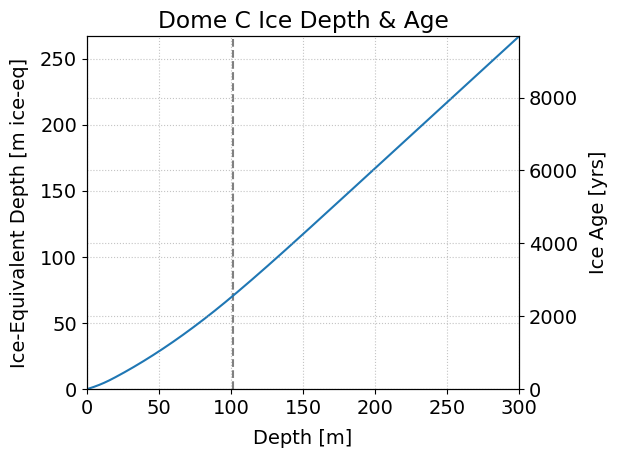

In [33]:
fig, ax = plt.subplots(1,1, tight_layout=True)

plt.axvline(Dome_C.z[Dome_C.teller_co], c='grey', ls='--')
plt.plot(Dome_C.z, Dome_C.IceAge * Dome_C.Acc, label='ice-eq depth')
plt.xlabel('Depth [m]')
plt.xlim(Dome_C.z[0],Dome_C.z[-1])
plt.ylim(Dome_C.IceAge[0]*Dome_C.Acc, Dome_C.IceAge[-1]*Dome_C.Acc)
plt.ylabel(r'Ice-Equivalent Depth [m ice-eq]')
#plt.legend(fontsize=10)
plt.title('Dome C Ice Depth & Age')

ax2 = ax.twinx()
ax2.set(
    ylabel='Ice Age [yrs]',
    ylim=(Dome_C.IceAge[0], Dome_C.IceAge[-1]),
)
plt.show()

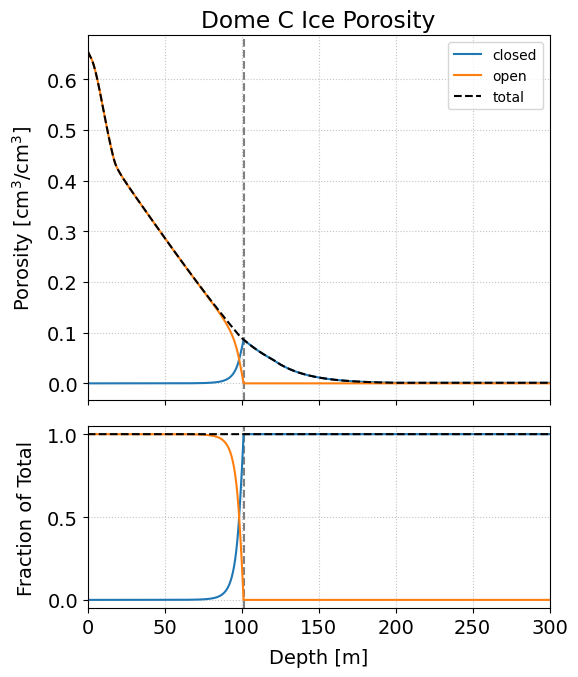

In [34]:
fig, axes = plt.subplots(2,1, figsize=(6,7), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

for ax in axes:
    ax.axvline(Dome_C.z[Dome_C.teller_co], c='grey', ls='--')

axes[0].plot(Dome_C.z, Dome_C.s_closed, label='closed')
axes[0].plot(Dome_C.z, Dome_C.s_open, label='open')
axes[0].plot(Dome_C.z, Dome_C.s, label='total', ls='--', c='k')

axes[1].plot(Dome_C.z, Dome_C.s_closed/Dome_C.s, label='closed')
axes[1].plot(Dome_C.z, Dome_C.s_open/Dome_C.s, label='open')
axes[1].plot(Dome_C.z, Dome_C.s/Dome_C.s, label='total', ls='--', c='k')

axes[0].set(
    ylabel = r'Porosity [cm$^3$/cm$^3$]',
    title='Dome C Ice Porosity',
)

axes[1].set(
    xlim = (Dome_C.z[0],Dome_C.z[-1]),
    xlabel = 'Depth [m]',
    ylabel = 'Fraction of Total',
)

axes[0].legend(fontsize=10)
#plt.suptitle('Dome C Ice Porosity')
plt.show()

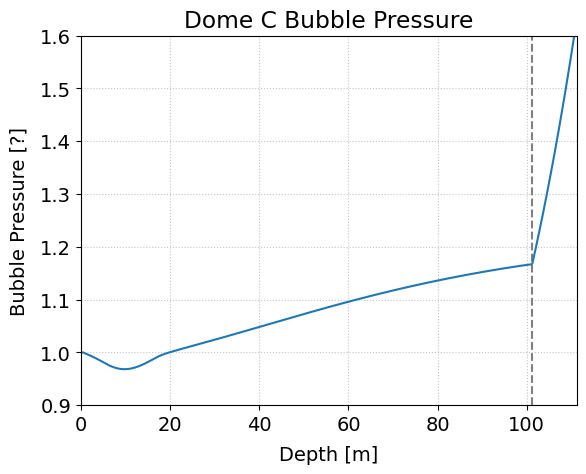

In [35]:
plt.axvline(Dome_C.z[Dome_C.teller_co], c='grey', ls='--')
plt.plot(Dome_C.z, Dome_C.bubble_pres)
plt.xlim(Dome_C.z[0],Dome_C.z[Dome_C.teller_co]+10)
plt.ylim(0.9,1.6)
plt.xlabel('Depth [m]')
plt.ylabel('Bubble Pressure [?]')
plt.title('Dome C Bubble Pressure')
plt.show()

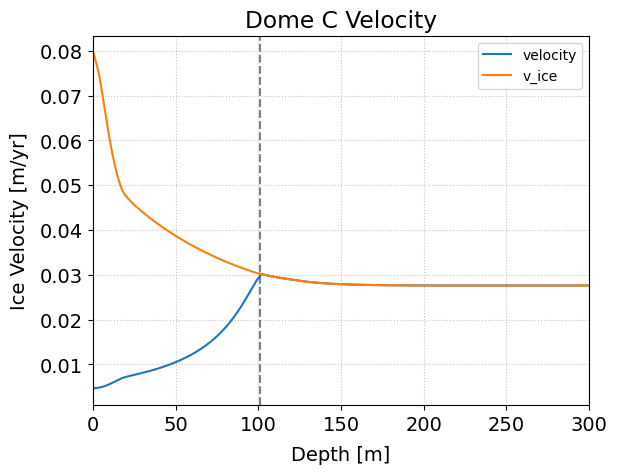

In [36]:
plt.axvline(Dome_C.z[Dome_C.teller_co], c='grey', ls='--')
plt.plot(Dome_C.z, Dome_C.velocity, label='velocity')
plt.plot(Dome_C.z, Dome_C.v_ice, label='v_ice')
plt.xlim(Dome_C.z[0],Dome_C.z[-1])
plt.xlabel('Depth [m]')
plt.ylabel('Ice Velocity [m/yr]')
plt.title('Dome C Velocity')
plt.legend(fontsize=10)
plt.show()

Text(0.5, 1.0, 'Dome C $^{14}$C Production Rates')

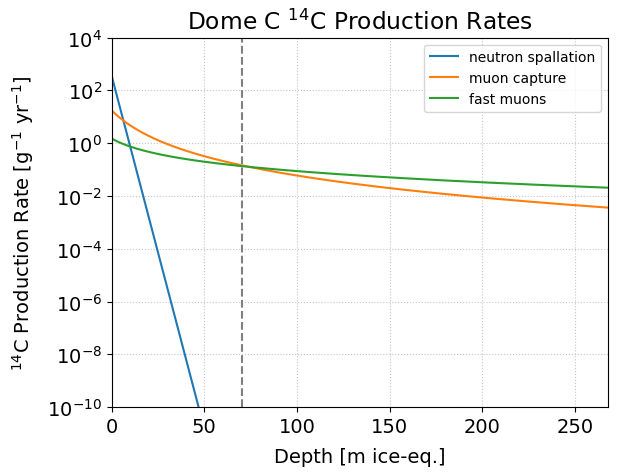

In [37]:
COS_dz = Dome_C.Acc * Dome_C.t_resol
COS_z = np.arange(COS_dz/2, Dome_C.dz * np.sum(Dome_C.rho)/Dome_C.rho_ice + 2 * Dome_C.dz, COS_dz) # depth bin centers

COS_Pn, COS_Pmu, COS_Pmuf = Dome_C.COS_Production(COS_z)

plt.axvline(Dome_C.Acc * Dome_C.IceAge[Dome_C.teller_co], c='grey', ls='--')
plt.plot(COS_z, COS_Pn, label='neutron spallation')
plt.plot(COS_z, COS_Pmu, label='muon capture')
plt.plot(COS_z, COS_Pmuf, label='fast muons')
plt.xlim(0,COS_z[-1])
plt.xlabel('Depth [m ice-eq.]')
plt.yscale('log')
plt.ylim(1e-10,1e+4)
plt.ylabel(r'$^{14}$C Production Rate [g$^{-1}$ yr$^{-1}$]')
plt.legend(fontsize=10)
plt.title(r'Dome C $^{14}$C Production Rates')

In [38]:
pd_DomeC = pd.read_excel('DomeC 14CO data analysis current.xlsx', '14CO vs depth',
                         header = 2, index_col=0,
                         usecols=[0,1,2,3,5,6], skiprows=[3,16,21,22,23])
pd_DomeC

,"Mean depth, m","14CO, molec / g ice after all corrections","Error, 1 sigma","Mean gas age, yr before 1950","Mean gas age, Years before measurement date"
Sample,,,,,
14CO_UR_DC_FIRN_SAMPLE_1,34.000,46.438967,1.143309,NaN,NaN
14CO_UR_DC_FIRN_SAMPLE_2,54.500,28.289650,0.749249,NaN,NaN
14CO_UR_DC_FIRN_EXTRACTION_3,75.000,18.807095,0.543124,NaN,NaN
14CO_UR_DC_ICE_SAMPLE_1,110.000,18.669397,0.885088,434.483581,510.483581
14CO_UR_DC_ICE_SAMPLE_3,150.000,26.848805,0.679599,1901.485970,1977.485970
14CO_UR_DC_ICE_SAMPLE_4,170.000,28.480674,0.573240,2717.573599,2793.573599
14CO_UR_DC_ICE_SAMPLE_5,190.500,29.289987,0.601586,3323.027758,3399.027758
14CO_UR_DC_ICE_SAMPLE_6,211.000,29.666008,0.722400,4118.909061,4194.909061
14CO_UR_DC_ICE_SAMPLE_7,230.925,28.951245,0.655983,4761.798084,4837.798084


In [39]:
z_exp, CO_exp, dCO_exp = pd_DomeC.to_numpy()[:,:3].T
i_samples = [0,3,12,len(z_exp)]
n_samples = ['Firn Sample', 'Borehole 1', 'Borehole 2']

z = Dome_C.z
teller_co = Dome_C.teller_co
lambd = Dome_C.decay_gas['C14_CO']
IceAge = Dome_C.IceAge

[1.00435613 0.03956094 0.07357688]
24.87374722707222
2.2612497479156564
0.009512559941534004
2.5930620749920097


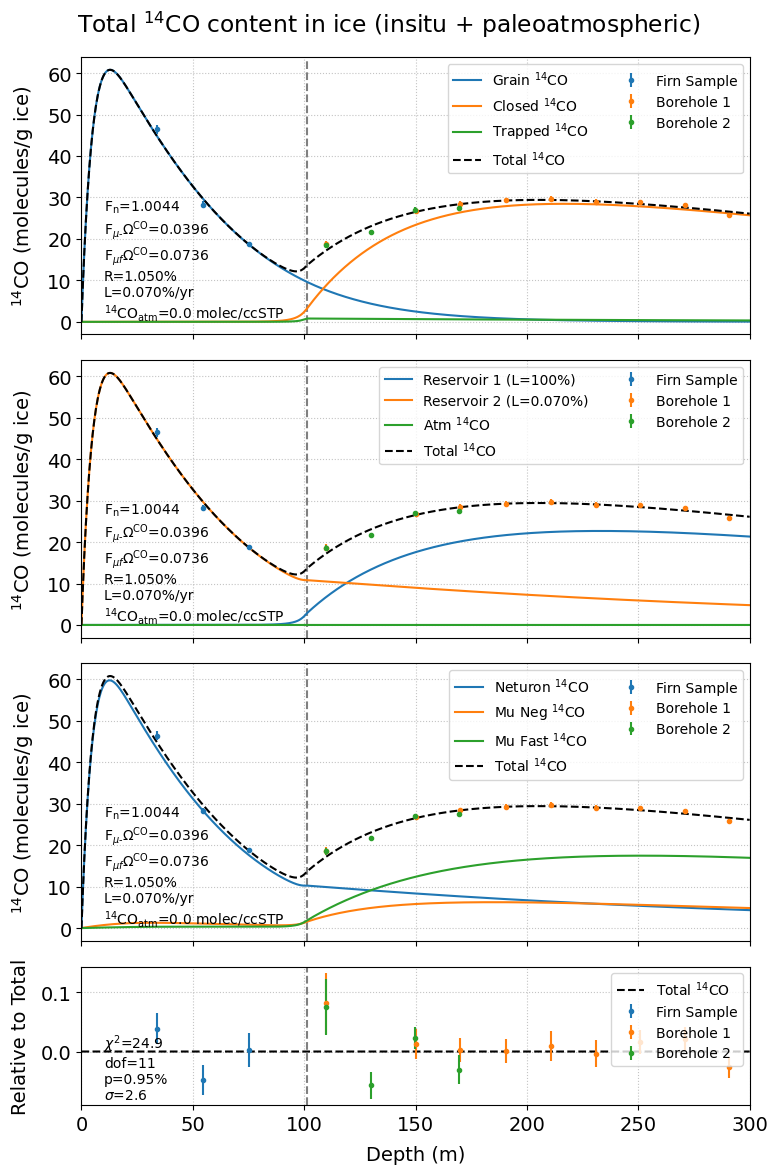

In [40]:
g = 'C14_CO'

i_avg = np.arange(len(CO_exp)).reshape((-1,1))
#i_avg = [[0],[1],[2],[3,12],[13],[4,14],[5,15],[6],[7],[8],[9],[10],[11]]
z_exp_avg = np.array([np.average(z_exp[i]) for i in i_avg])
CO_exp_avg = np.array([np.average(CO_exp[i]) for i in i_avg])
dCO_exp_avg = np.array([np.sqrt(np.sum(dCO_exp[i]**2)/len(i)**2+(np.std(CO_exp[i]))**2) for i in i_avg])
Sigma_inv = np.diag(dCO_exp_avg**(-2))

L1 = 7.1e-4
i_R = np.argmin(abs(L-L1))
R1 = 0.0105
#R1 = 0.01
R = np.zeros(len(L))
R[0] = 1-R1
R[i_R] = R1
R = R/sum(R)

CO_prod = np.array([COS_partition[0,1], 1, 1]).reshape((1,-1,1)) * (C14_grains + C14_cumuleak_closed + C14_closed_gas[g]) @ R
CO_atm = C14_closed_atm[g]

#CO_prod_int = interp1d(z, np.concatenate((CO_prod, np.array([CO_atm]).T), axis=1), axis=0)(z_exp_avg)
CO_prod_int = interp1d(z, CO_prod, axis=0)(z_exp_avg)
CO_pi = np.linalg.inv(CO_prod_int.T @ Sigma_inv @ CO_prod_int) @ CO_prod_int.T @ Sigma_inv

f_inv = CO_pi @ CO_exp_avg
print(f_inv)

#f_factors = np.array([1., 0.0538, 0.0685])
#f_factors = np.array([1., 0.0584, 0.0687])
f_factors = f_inv[:3]
P0_tuning = f_factors / np.array([1, COS_partition[0,1], COS_partition[0,1]])
#F_atm = 12 # atmospheric scale factor
F_atm = 0
#F_atm = f_inv[3]

fig, axes = plt.subplots(4,1, figsize=(8,12), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,2,2,1])

for ax in axes:
    ax.axvline(z[teller_co], c='grey', ls='--')

CO_grains = (P0_tuning * COS_partition[:,1]) @ C14_grains @ R
CO_closed = (P0_tuning * COS_partition[:,1]) @ C14_cumuleak_closed @ R
CO_openclose = (P0_tuning * COS_partition[:,1]) @ C14_closed_gas[g] @ R
CO_atm = C14_closed_atm[g]*F_atm
CO_all = CO_grains + CO_closed + CO_openclose + CO_atm

CO_res = (P0_tuning * COS_partition[:,1]) @ (C14_grains + C14_cumuleak_closed + C14_closed_gas[g]) * R[None,:]

CO_prod = (P0_tuning * COS_partition[:,1]).reshape((1,-1,1)) * (C14_grains + C14_cumuleak_closed + C14_closed_gas[g]) @ R

CO_firn = np.copy(CO_all)
CO_firn[teller_co:] = CO_firn[teller_co]*np.exp(lambd*(IceAge[teller_co]-IceAge[teller_co:]))

#noleak = C14_noleak @ (P0_tuning * COS_partition[:,1])
#rel = CO_firn + noleak
axes[0].plot(z, CO_grains, label=r'Grain $^{14}$CO')
axes[0].plot(z, CO_closed, label=r'Closed $^{14}$CO')
axes[0].plot(z, CO_openclose, label=r'Trapped $^{14}$CO')
#axes[0].plot(z, CO_atm, label=r'Atm $^{14}$CO')

axes[1].plot(z, CO_res[:,0], label=r'Reservoir 1 (L={:.0f}%)'.format(L[0]*100))
axes[1].plot(z, CO_res[:,i_R], label=r'Reservoir 2 (L={:.3f}%)'.format(L[i_R]*100))
axes[1].plot(z, CO_atm, label=r'Atm $^{14}$CO')

axes[2].plot(z, CO_prod[:,0], label=r'Neturon $^{14}$CO')
axes[2].plot(z, CO_prod[:,1], label=r'Mu Neg $^{14}$CO')
axes[2].plot(z, CO_prod[:,2], label=r'Mu Fast $^{14}$CO')
#axes[2].plot(z, CO_atm, label=r'Atm $^{14}$CO')


#axes[0].plot(z, CO_firn, label=r'Firn $^{14}$CO')
#axes[0].plot(z, noleak, label=r'In situ $^{14}$CO')
#axes[0].plot(z, CO_firn + noleak, label=r'Total $^{14}$CO', c='k', ls='--')
#axes[0].plot(z, CO_all, label=r'Total $^{14}$CO', c='k', ls='--')

for ax in axes[:-1]:
    ax.plot(z, CO_all, label=r'Total $^{14}$CO', c='k', ls='--')

rel = CO_all
    
axes[-1].plot(z, CO_all/rel-1, label=r'Total $^{14}$CO', c='k', ls='--')

for ax in axes:
    ax.set_prop_cycle(None)

CO_pred = np.interp(z_exp_avg, z, CO_all)

rel_exp = np.interp(z_exp, z, rel)
for i in range(len(n_samples)):
    j,k = i_samples[i],i_samples[i+1]
    for ax in axes[:-1]:
        ax.errorbar(z_exp[j:k], CO_exp[j:k], dCO_exp[j:k], fmt='.', label=n_samples[i])
    axes[-1].errorbar(z_exp[j:k], CO_exp[j:k]/rel_exp[j:k]-1, dCO_exp[j:k]/rel_exp[j:k], fmt='.', label=n_samples[i])
#axes[1].errorbar(z_exp_avg, CO_exp_avg/CO_pred-1, dCO_exp_avg/CO_pred, fmt='.', label='Sample Avg.')
    
for ax in axes[:-1]:
    ax.set(
        #xlabel='Depth (m)',
        #xlim=(z[0],z[-1]),
        ylabel=r'$^{14}$CO (molecules/g ice)',
        #title=r'Total $^{14}$CO content in ice (insitu + paleoatmospheric)',
    )

axes[-1].set(
    xlabel='Depth (m)',
    xlim=(z[0],z[-1]),
    ylabel='Relative to Total',
    #title=r'Total $^{14}$CO content in ice (insitu + paleoatmospheric)',
)

for ax in axes[:-1]:
    ax.text(10,1,r'$\text{F}_\text{n}$='+'{:.4f}\n'.format(f_factors[0])+r'$\text{F}_{\mu\text{-}}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[1])+r'$\text{F}_{\mu f}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[2])+'R={:.3f}%\nL={:.3f}%/yr\n'.format(R[i_R]*100,L[i_R]*100)+r'$^{14}\text{CO}_{\text{atm}}$='+'{:.1f} molec/ccSTP'.format(F_atm), fontsize=10)
    ax.legend(fontsize=10, loc='upper right', ncols=2)
axes[-1].legend(fontsize=10, loc='upper right', ncols=1)

dof = len(CO_exp_avg)-5
chi2 = np.sum((CO_exp_avg-CO_pred)**2/dCO_exp_avg**2)
p = scipy.stats.chi2.sf(chi2, dof)
sig = scipy.stats.norm.isf(p/2)
print(chi2)
print(chi2/dof)
print(p)
print(sig)

axes[-1].text(10,-.08,r'$\chi^2$='+'{:.1f}\n'.format(chi2)+'dof={}\np={:.2f}%\n'.format(dof,p*100)+r'$\sigma$={:.1f}'.format(sig), fontsize=10)

plt.suptitle(r'Total $^{14}$CO content in ice (insitu + paleoatmospheric)')

plt.show()

In [41]:
(CO_exp_avg-CO_pred)/dCO_exp_avg

array([ 1.51221574, -1.92640247,  0.10242557,  1.58107136,  0.48167117,
        0.14452171,  0.05591377,  0.37307433, -0.17873184,  0.81543864,
        1.11294529, -1.48711874,  1.58286859, -2.51764761,  1.18552045,
       -1.25455427])

/tmp/ipykernel_856/2544701078.py:12: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(z, grains[:,1:]/grains[:,None,i_R])


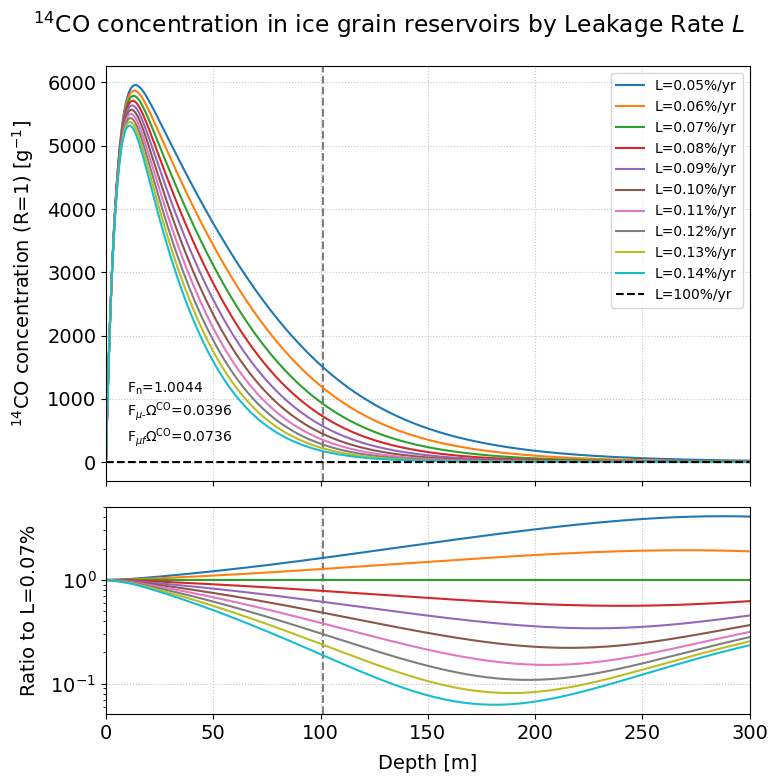

In [42]:
fig, axes = plt.subplots(2,1, figsize=(8,8), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

grains = (P0_tuning * COS_partition[:,1]) @ C14_grains


for ax in axes:
    ax.axvline(Dome_C.z[Dome_C.teller_co], c='grey', ls='--')

for i,gr in enumerate(grains.T[1:]):
    axes[0].plot(z, gr, label='L={:.2f}%/yr'.format(L[i+1]*100))
axes[0].plot(z, grains[:,0], ls='--', c='k', label='L={:.0f}%/yr'.format(L[0]*100))
axes[1].plot(z, grains[:,1:]/grains[:,None,i_R])

axes[0].set(
    ylabel=r'$^{14}$CO concentration (R=1) [g$^{-1}$]'
)

axes[1].set(
    xlim=(z[0],z[-1]),
    xlabel='Depth [m]',
    yscale='log',
    ylabel='Ratio to L={:.2f}%'.format(L[i_R]*100),
)

axes[0].text(10,1,r'$\text{F}_\text{n}$='+'{:.4f}\n'.format(f_factors[0])+r'$\text{F}_{\mu\text{-}}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[1])+r'$\text{F}_{\mu f}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[2]), fontsize=10)

axes[0].legend(fontsize=10)
plt.suptitle(r'$^{14}$CO concentration in ice grain reservoirs by Leakage Rate $L$')
plt.show()

/tmp/ipykernel_856/1031608849.py:17: RuntimeWarning: invalid value encountered in divide
  axes[1,0].plot(z, leak_open[:,1:]/leak_open[:,None,i_R])
/tmp/ipykernel_856/1031608849.py:18: RuntimeWarning: invalid value encountered in divide
  axes[1,1].plot(z, leak_closed[:,1:]/leak_closed[:,None,i_R])


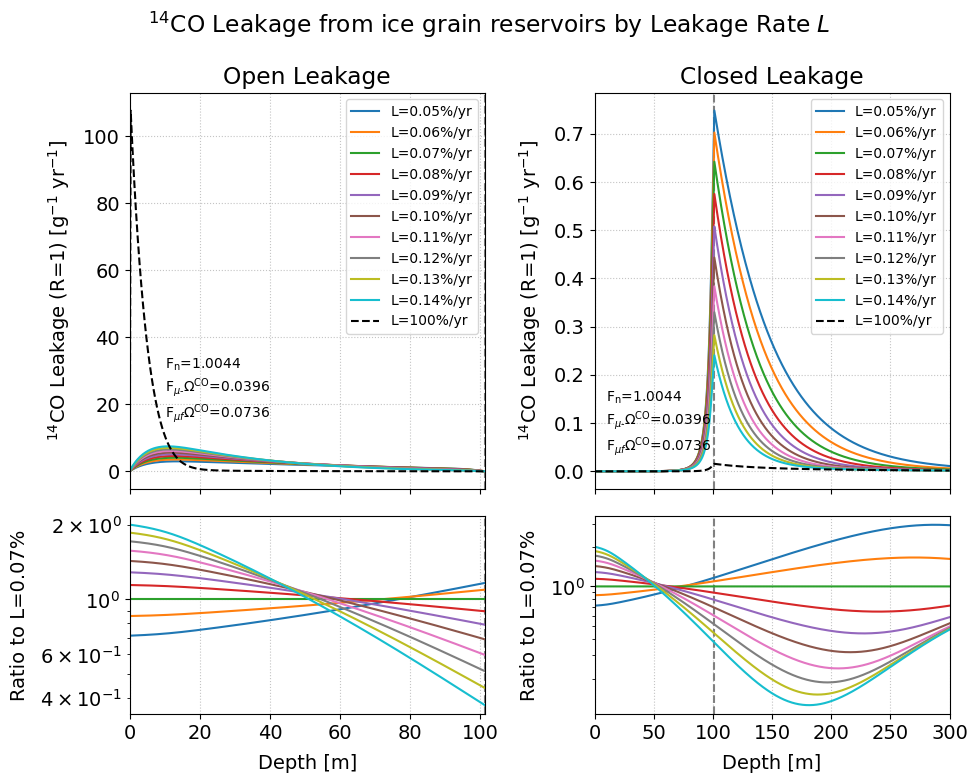

In [43]:
fig, axes = plt.subplots(2,2, figsize=(10,8), tight_layout=True, sharex = 'col', sharey=False, height_ratios=[2,1])

leak_open = (P0_tuning * COS_partition[:,1]) @ C14_leak_open

leak_closed = (P0_tuning * COS_partition[:,1]) @ C14_leak_closed

for axe in axes:
    for ax in axe:
        ax.axvline(Dome_C.z[Dome_C.teller_co], c='grey', ls='--')

for i,l in enumerate(leak_open.T[1:]):
    axes[0,0].plot(z, l, label='L={:.2f}%/yr'.format(L[i+1]*100))
for i,l in enumerate(leak_closed.T[1:]):
    axes[0,1].plot(z, l, label='L={:.2f}%/yr'.format(L[i+1]*100))
axes[0,0].plot(z, leak_open[:,0], ls='--', c='k', label='L={:.0f}%/yr'.format(L[0]*100))
axes[0,1].plot(z, leak_closed[:,0], ls='--', c='k', label='L={:.0f}%/yr'.format(L[0]*100))
axes[1,0].plot(z, leak_open[:,1:]/leak_open[:,None,i_R])
axes[1,1].plot(z, leak_closed[:,1:]/leak_closed[:,None,i_R])

axes[0,0].set(
    ylabel=r'$^{14}$CO Leakage (R=1) [g$^{-1}$ yr$^{-1}$]',
    title='Open Leakage'
)

axes[1,0].set(
    xlim=(z[0],z[Dome_C.teller_co]),
    xlabel='Depth [m]',
    yscale='log',
    ylabel='Ratio to L={:.2f}%'.format(L[i_R]*100),
)

axes[0,1].set(
    ylabel=r'$^{14}$CO Leakage (R=1) [g$^{-1}$ yr$^{-1}$]',
    title='Closed Leakage'
)

axes[1,1].set(
    xlim=(z[0],z[-1]),
    xlabel='Depth [m]',
    yscale='log',
    ylabel='Ratio to L={:.2f}%'.format(L[i_R]*100),
)

axes[0,0].text(10,10,r'$\text{F}_\text{n}$='+'{:.4f}\n'.format(f_factors[0])+r'$\text{F}_{\mu\text{-}}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[1])+r'$\text{F}_{\mu f}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[2]), fontsize=10)
axes[0,1].text(10,0,r'$\text{F}_\text{n}$='+'{:.4f}\n'.format(f_factors[0])+r'$\text{F}_{\mu\text{-}}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[1])+r'$\text{F}_{\mu f}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[2]), fontsize=10)

axes[0,0].legend(fontsize=10)
axes[0,1].legend(fontsize=10)
plt.suptitle(r'$^{14}$CO Leakage from ice grain reservoirs by Leakage Rate $L$')
plt.show()

/tmp/ipykernel_856/160871027.py:14: RuntimeWarning: invalid value encountered in divide
  axes[1].plot(z, open_gas[:,1:]/open_gas[:,None,i_R]-1)


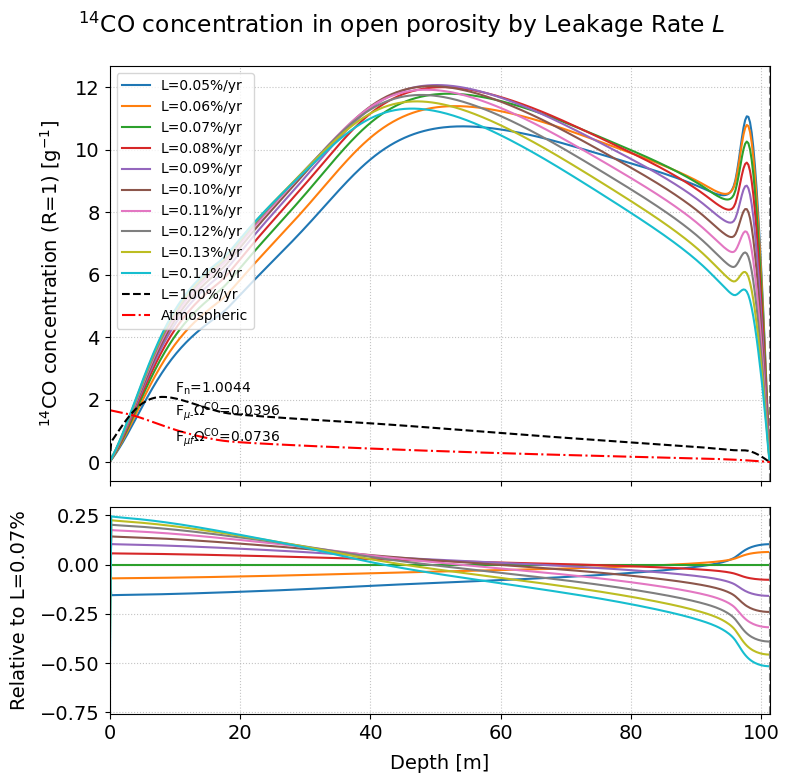

In [44]:
open_gas = (P0_tuning * COS_partition[:,1]) @ C14_open_gas[g]
open_atm = C14_open_atm[g]

fig, axes = plt.subplots(2,1, figsize=(8,8), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])


for ax in axes:
    ax.axvline(Dome_C.z[Dome_C.teller_co], c='grey', ls='--')

for i,op in enumerate(open_gas.T[1:]):
    axes[0].plot(z, op, label='L={:.2f}%/yr'.format(L[i+1]*100))
axes[0].plot(z, open_gas[:,0], ls='--', c='k', label='L={:.0f}%/yr'.format(L[0]*100))
axes[0].plot(z, open_atm, ls='-.', c='r', label='Atmospheric')
axes[1].plot(z, open_gas[:,1:]/open_gas[:,None,i_R]-1)

axes[0].set(
    ylabel=r'$^{14}$CO concentration (R=1) [g$^{-1}$]'
)

axes[1].set(
    xlim=(z[0],z[Dome_C.teller_co]),
    xlabel='Depth [m]',
    #yscale='log',
    ylabel='Relative to L={:.2f}%'.format(L[i_R]*100),
)

axes[0].text(10,0,r'$\text{F}_\text{n}$='+'{:.4f}\n'.format(f_factors[0])+r'$\text{F}_{\mu\text{-}}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[1])+r'$\text{F}_{\mu f}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[2]), fontsize=10)

axes[0].legend(fontsize=10, loc='upper left')
plt.suptitle(r'$^{14}$CO concentration in open porosity by Leakage Rate $L$')
plt.show()

/tmp/ipykernel_856/2108735720.py:21: RuntimeWarning: invalid value encountered in divide
  axes[1,0].plot(z, close[:,1:]/close[:,None,i_R])


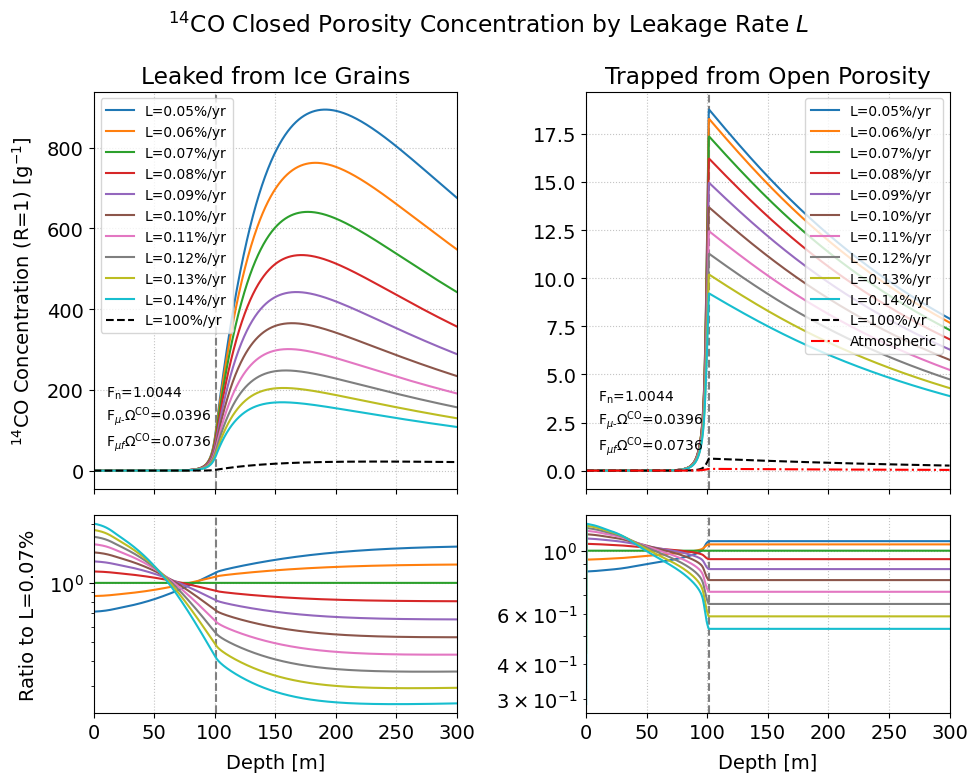

In [45]:
fig, axes = plt.subplots(2,2, figsize=(10,8), tight_layout=True, sharex = True, sharey=False, height_ratios=[2,1])

trap = (P0_tuning * COS_partition[:,1]) @ C14_closed_gas[g]

trap_atm = C14_closed_atm[g]

close = (P0_tuning * COS_partition[:,1]) @ C14_cumuleak_closed

for axe in axes:
    for ax in axe:
        ax.axvline(z[Dome_C.teller_co], c='grey', ls='--')

for i,l in enumerate(trap.T[1:]):
    axes[0,1].plot(z, l, label='L={:.2f}%/yr'.format(L[i+1]*100))
for i,l in enumerate(close.T[1:]):
    axes[0,0].plot(z, l, label='L={:.2f}%/yr'.format(L[i+1]*100))
axes[0,1].plot(z, trap[:,0], ls='--', c='k', label='L={:.0f}%/yr'.format(L[0]*100))
axes[0,1].plot(z, trap_atm, ls='-.', c='r', label='Atmospheric')
axes[0,0].plot(z, close[:,0], ls='--', c='k', label='L={:.0f}%/yr'.format(L[0]*100))
axes[1,1].plot(z, trap[:,1:]/trap[:,None,i_R])
axes[1,0].plot(z, close[:,1:]/close[:,None,i_R])

axes[0,0].set(
    ylabel=r'$^{14}$CO Concentration (R=1) [g$^{-1}$]',
    title='Leaked from Ice Grains'
)

axes[1,0].set(
    xlim=(z[0],z[-1]),
    xlabel='Depth [m]',
    yscale='log',
    ylabel='Ratio to L={:.2f}%'.format(L[i_R]*100),
)

axes[0,1].set(
    #ylabel=r'$^{14}$CO Leakage (R=1) [g$^{-1}$ yr$^{-1}$]',
    title='Trapped from Open Porosity'
)

axes[1,1].set(
    xlim=(z[0],z[-1]),
    xlabel='Depth [m]',
    yscale='log',
    #ylabel='Ratio to L={:.2f}%'.format(L[i_R]*100),
)

axes[0,0].text(10,10,r'$\text{F}_\text{n}$='+'{:.4f}\n'.format(f_factors[0])+r'$\text{F}_{\mu\text{-}}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[1])+r'$\text{F}_{\mu f}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[2]), fontsize=10)
axes[0,1].text(10,0,r'$\text{F}_\text{n}$='+'{:.4f}\n'.format(f_factors[0])+r'$\text{F}_{\mu\text{-}}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[1])+r'$\text{F}_{\mu f}\Omega^{\text{CO}}$='+'{:.4f}\n'.format(f_factors[2]), fontsize=10)

axes[0,0].legend(fontsize=10)
axes[0,1].legend(fontsize=10, loc='upper right')
plt.suptitle(r'$^{14}$CO Closed Porosity Concentration by Leakage Rate $L$')
plt.show()

[(0.0, 101.25), Text(0.5, 0, 'Depth [m]'), Text(0, 0.5, '$\\gamma$ [/yr]')]

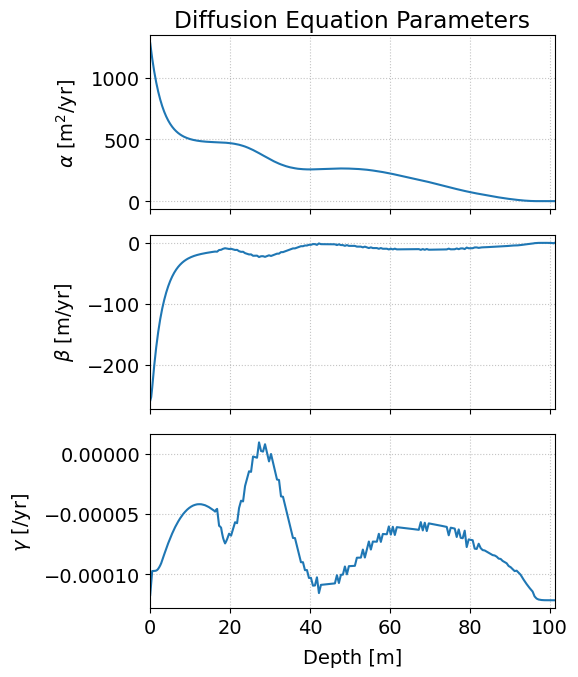

In [46]:
fig, axes = plt.subplots(3,1, figsize=(6,7), tight_layout=True, sharex = True, sharey=False)

axes[0].plot(z, Dome_C.alpha[g]*2*Dome_C.dz**2/Dome_C.dt)
axes[1].plot(z, Dome_C.beta[g]*4*Dome_C.dz/Dome_C.dt)
axes[2].plot(z, Dome_C.gamma[g]*2/Dome_C.dt)

axes[0].set(
    ylabel=r'$\alpha$ [m$^2$/yr]',
    title='Diffusion Equation Parameters'
)

axes[1].set(
    ylabel=r'$\beta$ [m/yr]'
)

axes[2].set(
    xlim=(z[0],z[Dome_C.teller_co]),
    xlabel='Depth [m]',
    ylabel=r'$\gamma$ [/yr]'
)

#plt.suptitle('Diffusion Equation Parameters')

# Accumulation Tensor

Below I've rewritten my accumulation tensor formalization of the production model to account for production in the firn:

$$\hat{A}_{grains}(a,t_a, p,t_p) = R\hat{T}(a, t_a, p, t_p)e^{(\lambda-\ln(1-L))(t_p-t_a)}\,dt_p$$

$$\vec{c}_{grains} = \hat{A}_{grains}\vec{P}\vec{f}\vec{\phi}$$

$\hat{T}(a, t_a, p, t_p)$ - Tensor for interpolating from the production depth $p$ to the depth $z(a,t_a,t_p)$ at time of production $t_p$ of an ice parcel with depth $a$ at time $t_a$

$R$ - Retention into slow-leaking reservoir

$L$ - Annual leakage from slow-leaking reservoir (the leakage rate $-\ln(1-L)$ is the more useful value)

$\lambda$ - 14C decay rate

$$\hat{A}_{open}(a,t_a,p,t_p) = \hat{D}^{(t_a-t_a')/dt}(a,t_a,a',t_a')U_{g\rightarrow ppm}(a')\frac{s_o(a')}{s(a')}((1-R)\hat{T}(a',p) - \ln(1-L) \hat{A}_{grains}(a',t_a',p,t_p))\,dt_a'$$

$$\hat{A}_{open}^{atm}(a,t_a,t_p) = \hat{D}^{(t_a-t_p)/dt}(a,t_a,0,t_p)\,dt_p$$

$$\vec{c}_{open} = \hat{A}_{open}\vec{P}\vec{f}\vec{\phi} + \hat{A}_{open}^{atm}\vec{c}^{atm}$$

$\hat{T}(a',p)$ - Tensor for interpolating from the production depth $p$ to ice parcel depth $a'$

$U_{g \rightarrow ppm}(a)$ - Unit conversion from molecules per gram of ice to ppm

$\hat{D}(a,a')$ - Crank-Nicholson Diffusion tensor $= (1-A)^{-1}(1+A)$

$s_o/s$ - Open fraction of porosity

$$\hat{A}_{closed}(a,p,t) = \hat{T}(a, a', t')[\frac{s_c(a')}{s(a')}((1-R)\hat{T}(a',p) - \ln(1-L) \hat{A}_{grains}(a',t',p,t)) + U_{ppm\rightarrow g}(a')tr(a')\hat{A}_{open}(a',t',p,t)]e^{\lambda t'}\,dt'$$

$$\hat{A}_{closed}^{atm}(a,t) = \hat{T}(a,a',t') U_{ppm\rightarrow g}(a')tr(a')\hat{A}_{open}^{atm}(a',t',t)e^{\lambda t'}\,dt'$$

$$\vec{c}_{closed} = \hat{A}_{closed}\vec{P}\vec{f}\vec{\phi} + \hat{A}_{closed}^{atm}\vec{c}^{atm}$$

$\hat{T}(a,a',t')$ - Tensor for interpolating from depth $a'$ to the depth $z(a,0,t')$ at time $t'$ of an ice parcel with present depth $a$

$U_{ppm\rightarrow g}(a)$ - Unit conversion from ppm to molecules per gram of ice

$tr(a,t)$ - Trapping rate at depth $a$, normalized to present total trapped gas; $=\rho(a)\frac{d(s_o b_p)}{dz}(a) / \int \rho(z(t))\frac{d(s_o b_p)}{dz}(z(t))\, dt$

$s_c/s$ - Closed fraction of porosity

To try and avoid constantly interpolating between different depth grids, let's be consistent and just follow the same ice parcels from start to finish.

Noteably, if the real-depth size of our ice parcels changes over time (for instance, as they compact), it may change the concentration of 14CO within open porosity, depending on the units.  Generally, we'll want to stay in molecules per gram, but the diffusion tensor assumes ppm, so we'll have to factor a unit conversion into that tensor, making sure to account for this effect.

Assuming $\vec{P}$ and $\vec{\phi}$ are both sampled along our time-integration grid:

$$\vec{c}^{\text{grains}}_{a,t} = \sum_{t'}(\vec{R}\cdot\hat{A}^{\text{grains}})_{t'}(\vec{P}\cdot\vec{f})_{a+At'}\vec{\phi}_{t'+t} = \sum_{t',p} (\vec{R}\cdot\hat{A}^{\text{grains}})_{t'}\hat{\delta}_{p,a+At'}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t'+t}$$

$$\hat{A}^{\text{grains}}_{r,t} = e^{(\lambda+\vec{l}_r)t}dt$$

If they're sampled along a different grid, include a transformation to interpolate from one grid to another.

In [19]:
# A = np.exp((lambd - np.log(1-L)[:,None])*t[None,:]) * dt[None,:]

#N = len(t)
#i = np.arange(N)[:,None]
#j = np.arange(N)[:,None]
#a = np.arange(N)[None,:]-N
#c = np.einsum('a,ia,ja->ij', R @ A, (P @ f)[(i+a).clip(min=0)]*(i+a>=0), phi[(j+a).clip(min=0)]*(j+a>=0))
#i - final depth
#j - final time
#a - integration time
# how to make it so out-of-bounds error = 0?
# god I wish einsum had built-in indexing functionality!  Like,
#c = np.einsum('a,i+a,j+a->ij', R@A, P@f, phi)
# imagine that world...

In [20]:
Dome_C.IceAge.shape

(1201,)

In [21]:
t = Dome_C.IceAge
#t_a = t.reshape((1,-1,1,1,1))
#t_p = ((t[:-1]+t[1:])/2).reshape((1,1,1,1,-1))
#Dt = t_a - t_p
#dt = np.diff(t).reshape((1,1,1,1,-1))
Dt = t - t[-1]
Dt = ((Dt[:-1]+Dt[1:])/2).reshape((1,1,1,-1))
dt = np.diff(t).reshape((1,1,1,-1))
L_mat = L[1:].reshape((1,1,-1,1))

In [22]:
h = (Dome_C.IceAge*Dome_C.Acc*Dome_C.rho_ice)[::10]
p = h.reshape((1,-1,1,1))
a = ((h[:-1]+h[1:])/2).reshape((-1,1,1,1))

In [23]:
#T_ptoa = np.zeros((len(h)-1, len(h), 1, len(Dt)))
#for i in range(len(Dt)):
    #T_ptoa[np.arange(i,len(h)-1),np.arange(len(h)-1-i),0,i] = 1.
a_prime = a-Dt*Dome_C.Acc*Dome_C.rho_ice
a_prime[a_prime<0] = -10
a_slope = ((a_prime - p[:,:-1])/np.diff(p,axis=1)).clip(0,1)
T_ptoa = np.concatenate([1*(a_prime>=p[:,0])-a_slope[:,:1], -np.diff(a_slope, axis=1), a_slope[:,-1:]-1*(a_prime>p[:,-1])], axis=1)

A_grains = T_ptoa * np.exp(-(lambd-np.log(1-L_mat)) * Dt) * dt
A_grains.shape
# axis0 - Accumulation Depth (a)
# axis1 - Production Depth (p)
# axis2 - Leakage Rate (L)
# axis3 - Accumulation Time - Production Time (Dt = t_a - t_p)

(120, 121, 1, 1200)

$$\vec{c}_{a,t} = \sum_{t'}D^{t'/dt'}U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}[(1-e^{\vec{L}dt'})(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t'+t} + \vec{L} \vec{c}^{\text{grains}}_{p,t'+t}]dt'$$

$$\vec{c}_{a,t} = \sum_{t'}D^{t'/dt'}U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}[(1-e^{\vec{L}dt'})(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t'+t} + \vec{L} \sum_{t''}\hat{A}^{\text{grains}}_{r,t''}(\vec{P}\cdot\vec{f})_{At''+p}\vec{\phi}_{t''+t'+t}]dt'$$

$$\vec{c}_{a,t} = \sum_{t'}D^{t'/dt'}(1-e^{\vec{L}dt'})U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}(\vec{P}\cdot\vec{f})_p\vec{\phi}_{t'+t}dt' + \sum_{t'}D^{t'/dt'}U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}\vec{L} \sum_{t''}^p\hat{A}^{\text{grains}}_{r,t''}(\vec{P}\cdot\vec{f})_{At''+p}\vec{\phi}_{t''+t'+t}dt'$$

$$A = \sum_{t'}D^{t'/dt'}(1-e^{\vec{L}dt'})U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}dt' + \sum_{t'}D^{t'/dt'}U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}\vec{L} \hat{A}^{\text{grains}}()$$

$$\vec{c}^{\text{open}}_{a,t} = \sum_{p=0}^{z_{co}}\sum_{t'=0}^{-\infty} \hat{A}_{a,p,t'} (\vec{P}\cdot\vec{f})_p \vec{\phi}_{t'+t}$$

$$\hat{A}^{\text{open}}_{a,p,t} = [D^t(1-e^{-ldt}) + l\sum_{t'=0}^{\text{min}((z_{co}-p)/A,t)} D^{t-t'}_{a,p-At'}e^{-(\lambda+l)t'}]U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}dt$$

$$\hat{A}^{\text{open}}_{a,p,t} = [\sum_{t'=0}^{\text{min}((z_{co}-p)/A,t)} D^{t-t'}_{a,p-At'} e^{-(\lambda+l)t'}](1-(1-L)^{dt})U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}dt$$

$$\hat{A}^{\text{open}}_{a,p,t} = S_{a,d}\cdot[\sum_{t'=0}^{\text{min}((z_{co}-p)/A,t)} \vec{d}^{t-t'}e^{-(\lambda+l)t'} S^T_{d,p-At'}](1-(1-L)^{dt})U_{g\rightarrow ppm}(p) \frac{s_o(p)}{s(p)}dt$$

$$\hat{A}^{\text{open}}_{a,p,t} = [\sum_{t'=0}^{\text{min}((z_{co}-p)/A,t)} D^{t-t'}_{a,a'} e^{-(\lambda+l)t'} \hat{U}_{a',p,t'}](1-(1-L)^{dt})dt$$

$$\hat{A}^{\text{open}}_{a,p,t} = S_{a,d}\cdot[\sum_{t'=0}^{\text{min}((z_{co}-p)/A,t)} \vec{d}^{t-t'} e^{-(\lambda+l)t'} S^T_{d,a'}\hat{U}_{a',p,t'}](1-(1-L)^{dt})dt$$

$$\hat{A}^{\text{open}}_{a,p,t} = [\sum_{a'}^{z_{co}}\sum_{t''=0}^t\sum_{t'=0}^{z_{co}/A} D^{t''}_{a,a'} U(a') e^{-(\lambda+l)t'} \delta_{t'',t-t'} \delta_{a',p+At'}](1-(1-L)^{dt})dt$$

$$\hat{U}_{a,p,t} = U(a)\hat{\delta}_{a,p+At} = U_{g\rightarrow ppm}(a) \frac{s_o(a)}{s(a)}\hat{\delta}_{a,p+At}$$

In [24]:
Site = Dome_C
gas = 'C14_CO'

alpha = Site.alpha[gas]
beta = Site.beta[gas]
gamma = Site.gamma[gas]

Q = Site.teller_co

A_for = scipy.sparse.diags_array(
    [
        np.concatenate((alpha[1:Q] - beta[1:Q], [0])),
        np.concatenate(([1], 1-2*alpha[1:Q]+gamma[1:Q], [0])),
        np.concatenate(([0], alpha[1:Q] + beta[1:Q] )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
)

A_back = scipy.sparse.diags_array(
    [
        np.concatenate((-1*(alpha[1:Q] - beta[1:Q]), [-1])),
        np.concatenate(([1], 1+2*alpha[1:Q]-gamma[1:Q], [1])),
        np.concatenate(([0], -1*(alpha[1:Q] + beta[1:Q]) )),
    ],
    offsets=np.arange(-1,2), shape=(Q,Q)
)


A_inv = scipy.sparse.linalg.inv(A_back)

D = A_inv @ A_for
D[0] = 0
D.shape

/home/wcook/.local/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Ainv = spsolve(A, I)
/home/wcook/.local/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


(405, 405)

In [25]:
gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)
gram_to_ppm[Site.teller_co:] = 0

U = (gram_to_ppm * Dome_C.s_open/Dome_C.s)[:Q]
U.shape

/tmp/ipykernel_639/4276165505.py:1: RuntimeWarning: divide by zero encountered in divide
  gram_to_ppm = 1e18*Site.R*Site.T / (6.022140857e23*Site.pressure*Site.s_open/Site.rho*np.exp(Site.M_air*Site.g*Site.z/(Site.R*Site.T))*1e-6)


(405,)

In [26]:
Lrate = -np.log(1-L)

/tmp/ipykernel_639/1558017006.py:1: RuntimeWarning: divide by zero encountered in log
  Lrate = -np.log(1-L)


In [27]:
def cum_mat_prod(A,N):
    # A can have any shape, as long as the last 2 axes are square
    A_cum = np.ones((N,*A.shape))
    A_cum[0] = np.identity(A.shape[-1])
    for i in tqdm(range(1,N)):
        A_cum[i] = A @ A_cum[i-1]
    return A_cum

In [28]:
N_t = 1000
l = np.arange(len(L))
a = np.arange(Q)
a2 = np.arange(Q)
p = np.arange(Q)
t = np.arange(N_t)
t2 = np.arange(Q)
t3 = np.arange(N_t)

dt = Dome_C.dt

$$\vec{c}^{\text{open}}_{a,t} = \sum_{p=0}^{z_{co}}\sum_{t'=0}^{-\infty} \hat{A}_{a,p,t'} (\vec{P}\cdot\vec{f})_p \vec{\phi}_{t'+t}$$

$a$ - measurement depth

$t$ - measurement time

$p$ - production depth

$t'$ - time between production & measurement

$$\hat{A}^{\text{open}}_{a,p,t'} = [\sum_{t''=0}^{\text{age}_{co}} D^{-t'-t''}_{a,p+At''} U(p+At'') e^{-\lambda t''}(1-L)^{t''}(1-(1-L)^{dt''})]dt'$$

$t''$ - leak time; time spent in grain before leaking into open pores (can't be longer than age at close-off depth)

$-t'-t''$ - diffusion time; time spent diffusing in open porosity before measurement

$p + At''$ - leak depth; depth at time of leakage (A = accumulation rate)

$L$ - annual leakage rate (if $L<100\%$, $(1-L)^{t''}= e^{-lt''}$ and $(1-(1-L)^{dt''})=l dt''$)

$$U(a) = U_{g\rightarrow ppm}(a) \frac{s_o(a)}{s(a)}$$

$U(a)$ - open porosity fraction & unit conversion from per gram to ppm at depth $a$

In [77]:
D_t = np.moveaxis(cum_mat_prod(D,len(t3)),0,-1)
D_t.shape

100%|███████████████████████████████████████████████████████████████████████████████| 1999/1999 [00:42<00:00, 47.50it/s]


(405, 405, 2000)

In [ ]:
# apply our unit conversion ahead of time
# to avoid repetitive multiplication
DU = D_t*U[None,:,None]

# sum over t', with funky indexing to account for -t'-t''=diffusion time and p+At''=leak depth
A_open = np.zeros((len(l),len(a),len(p),len(t)))
for t2 in tqdm(range(Q)): #t2 = time spent in grains before leaking
    A_open[:,:,:-t2 if t2>0 else None,t2:] += DU[None,:,t2:,-t2-1::-1] * (np.exp(-lambd*t2*dt) * (1-L)**(t2*dt))[:,None,None,None]
A_open *= (1-(1-L)**dt)[:,None,None,None] * dt

  0%|                                                                                           | 0/405 [00:00<?, ?it/s]

$$\hat{A}_{open}^{atm}(a,t) = \hat{D}^{t/dt}(a,0)\,dt$$

$$\vec{c}^{open}_{a,t} = \sum_{t',p} (\vec{R}\cdot\hat{A}^{open})_{a,p,t'}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t'+t} + \sum_{t'}\hat{A}^{atm}_{a,t'}\vec{c}^{atm}_{t'+t}$$

In [ ]:
A_open_atm = D_t[:,0] * dt

$$\hat{A}_{closed}(a,p,t) = \hat{T}(a, a', t')[\frac{s_c(a')}{s(a')}((1-R)\hat{T}(a',p) - \ln(1-L) \hat{A}_{grains}(a',t',p,t)) + U_{ppm\rightarrow g}(a')tr(a')\hat{A}_{open}(a',t',p,t)]e^{\lambda t'}\,dt'$$

$$\hat{A}_{closed}^{atm}(a,t) = \hat{T}(a,a',t') U_{ppm\rightarrow g}(a')tr(a')\hat{A}_{open}^{atm}(a',t',t)e^{\lambda t'}\,dt'$$

$$\vec{c}_{closed} = \hat{A}_{closed}\vec{P}\vec{f}\vec{\phi} + \hat{A}_{closed}^{atm}\vec{c}^{atm}$$

$$\vec{c}^{closed}_{a,t} = \sum_{t'}^0 [\sum_{t''=0}^{-t'} \frac{s_c(a+At'+At'')}{s(a+At'+At'')}(1-(1-L)^{dt''})(1-L)^{t''}] e^{\lambda t'} (\vec{P}\cdot \vec{f})_{a+At'}\vec{\phi}_{t+t'}dt'$$

$$\vec{c}^{closed}_{a,t} = \sum_{t'} L_c(a,t') e^{\lambda t'} (\vec{P}\cdot \vec{f})_{a+At'}\vec{\phi}_{t+t'}dt'$$

$$\vec{c}^{trap}_{a,t} = U_{ppm\rightarrow g}(a)\sum_{t'} \vec{c}_{a,t+t'}^{open}e^{\lambda t'} Tr(a,t')dt'$$

$$Tr(a,t') = tr(a+At')/\sum_{t''} tr(a+At'') dt''$$

$$\vec{c}^{trap}_{a,t} = U_{ppm\rightarrow g}(a)\sum_{t'}e^{\lambda t'} Tr(a,t')dt' [\sum_{t'',p} (\vec{R}\cdot\hat{A}^{open})_{a,p,t''}(\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t+t'+t''} + \sum_{t''}\hat{A}^{atm}_{a,t''}\vec{c}^{atm}_{t+t'+t''}]$$

Redefine $t'=t'+t''$, $t''=t'$

$$\vec{c}^{trap}_{a,t} = U_{ppm\rightarrow g}(a)\sum_{t'}\sum_p [\sum_{t''}e^{\lambda (t'-t'')} Tr(a,t'-t'')dt' \hat{A}^{open}_{a,p,t''-t'}](\vec{P}\cdot\vec{f})_{p}\vec{\phi}_{t+t'}$$

$t'$ - time of production (relative to measurement)

$t''$ - time of trapping (relative to measurement)

$$\hat{A}^{trap}_{a,p,t'} = U_{ppm\rightarrow g}(a)\sum_{t''}e^{\lambda t''}Tr(a,t'')\hat{A}^{open}_{a,p,t'-t''}dt''$$

$t'$ - time of production (relative to measurement)

$t''$ - time of trapping (relative to measurement)